# Using polars Expressions with MplChart

Polars expression factories available in `mplchart.expressions` can create native polars expressions.
Pass them directly to `chart.plot()` just like regular indicators.



In [1]:
from mplchart.chart import Chart
from mplchart.samples import sample_prices
from mplchart.primitives import Candlesticks, Volume, LinePlot
from mplchart.expressions import (
    SMA, EMA, RMA, WMA, HMA, DEMA, TEMA,
    RSI, MACD, STOCH, ROC, MOM,
    TRANGE, ATR, BBANDS, DONCHIAN, KELTNER,
    AVGPRICE, MEDPRICE, TYPPRICE, WCLPRICE,
)

prices = sample_prices(backend="polars")

## Moving Averages

`SMA`, `EMA`, `RMA`, `WMA`, `HMA`, `DEMA`, `TEMA` — all accept an optional `src` expression.

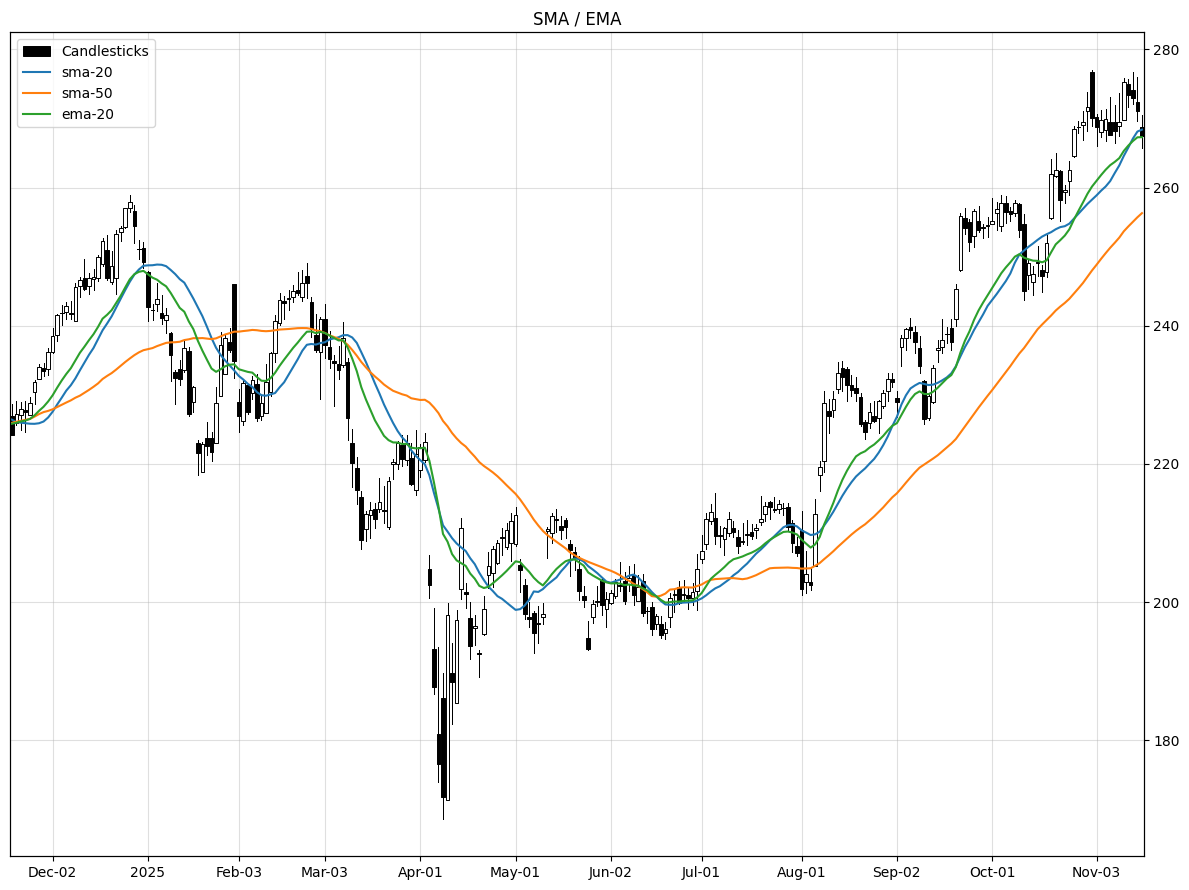

In [2]:
Chart(prices, title="SMA / EMA", max_bars=250).plot(
    Candlesticks(),
    SMA(20),
    SMA(50),
    EMA(20),
).show()

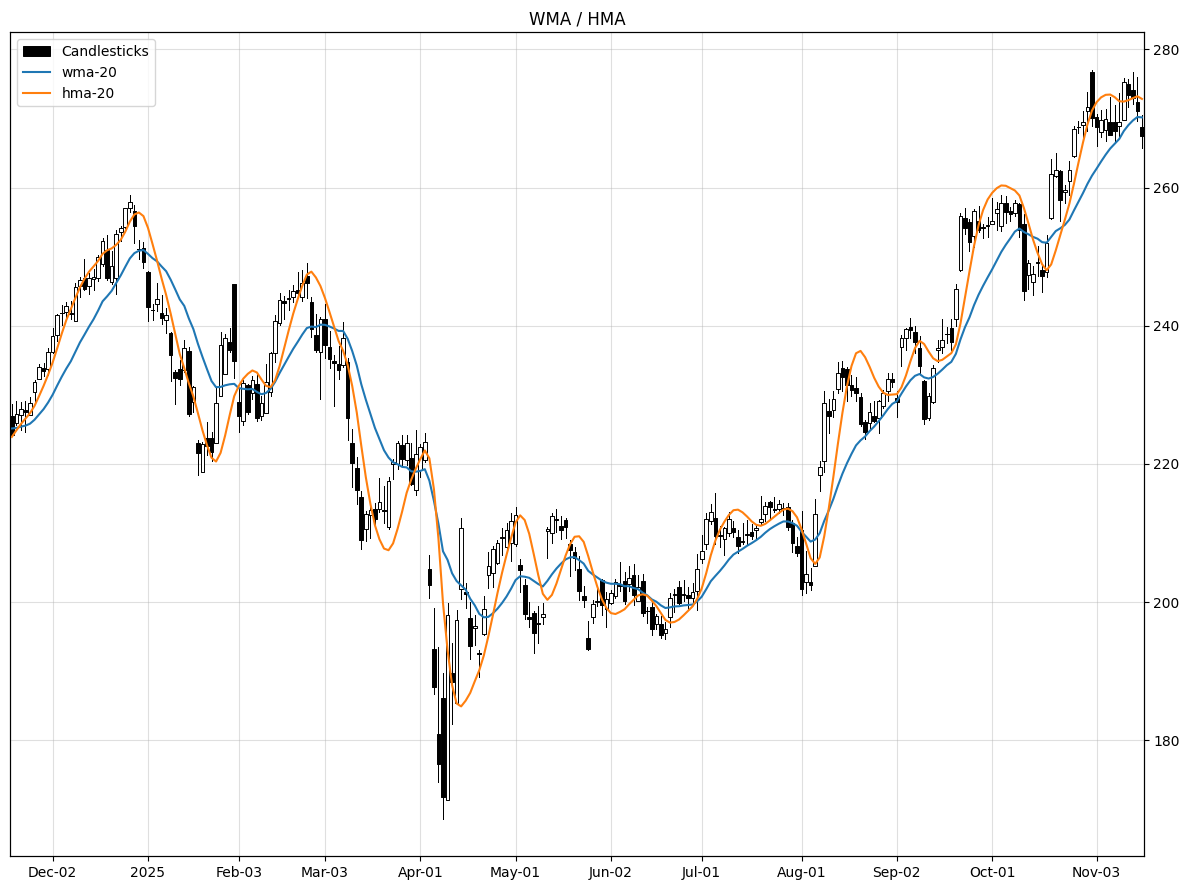

In [3]:
Chart(prices, title="WMA / HMA", max_bars=250).plot(
    Candlesticks(),
    WMA(20),
    HMA(20),
).show()

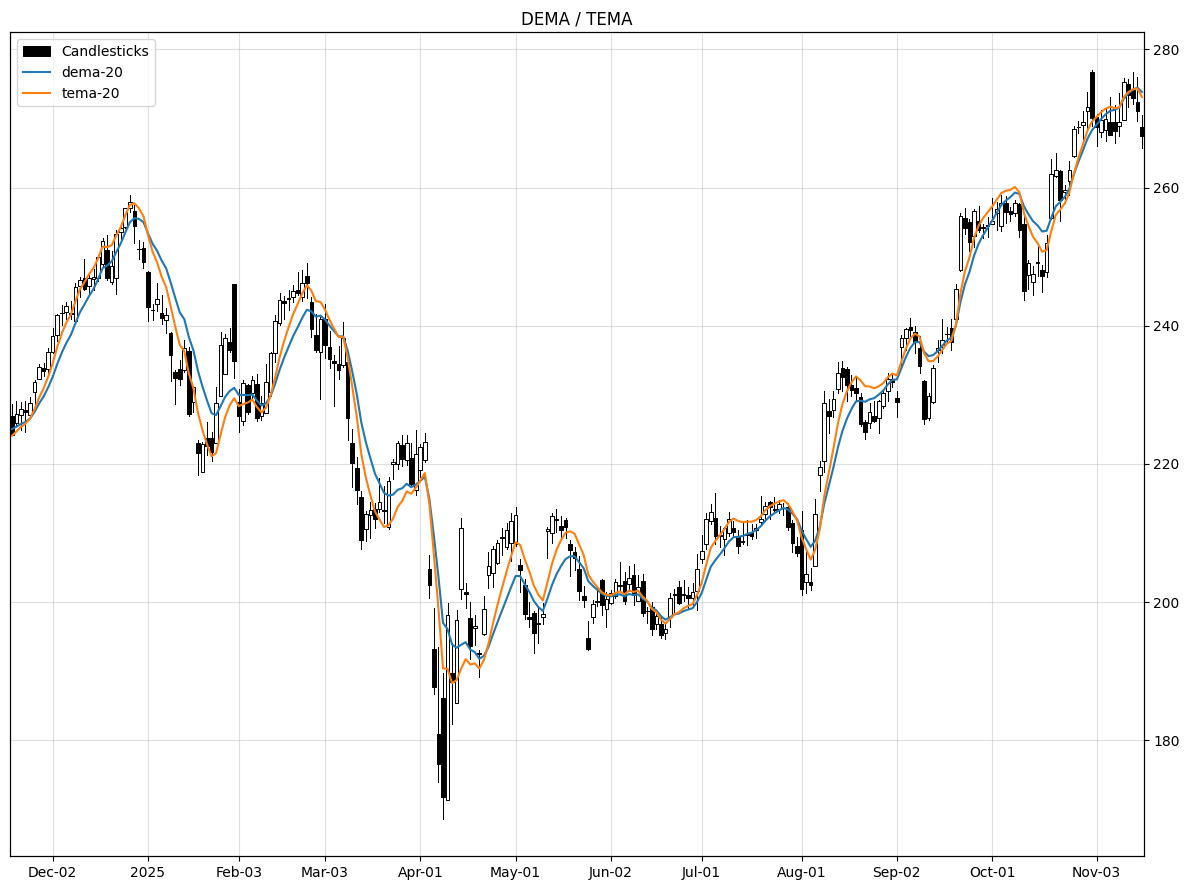

In [4]:
Chart(prices, title="DEMA / TEMA", max_bars=250).plot(
    Candlesticks(),
    DEMA(20),
    TEMA(20),
).show()

## RSI

Relative Strength Index. Accepts an optional `src` expression.

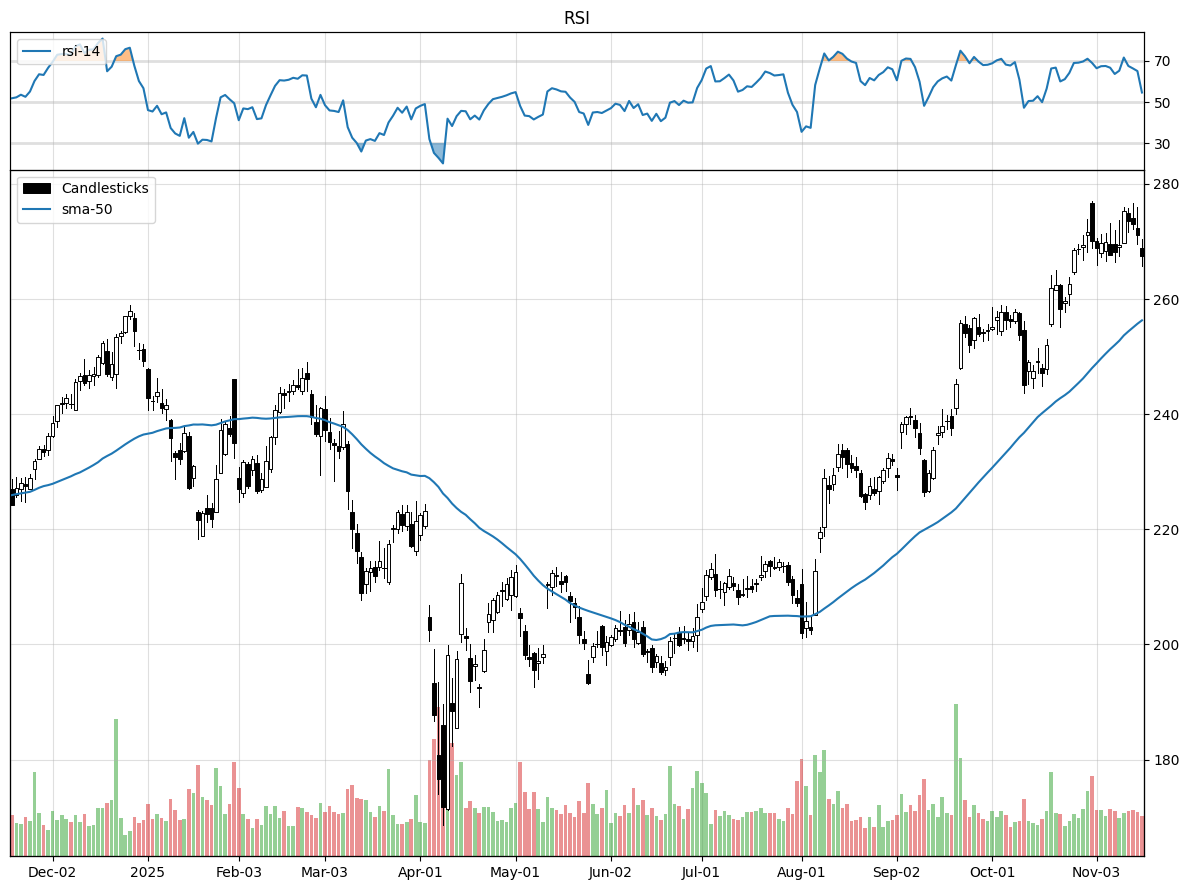

In [5]:
Chart(prices, title="RSI", max_bars=250).plot(
    Candlesticks(), SMA(50), Volume(),
).pane("above", yticks=(30, 50, 70)).plot(
    LinePlot(RSI(14), overbought=70, oversold=30),
).show()

## MACD

Moving Average Convergence Divergence — returns `(macd, signal, hist)`.

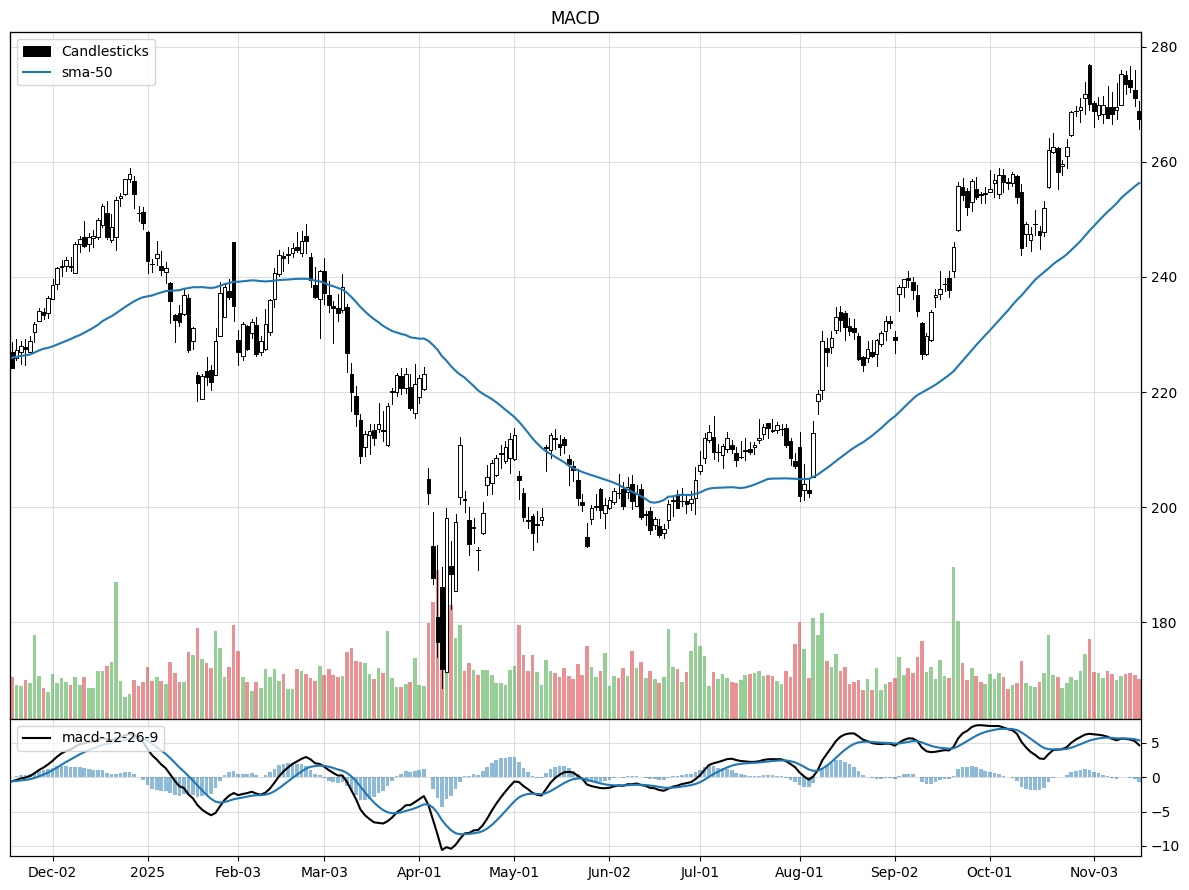

In [6]:
Chart(prices, title="MACD", max_bars=250).plot(
    Candlesticks(), SMA(50), Volume(),
).pane("below").plot(
    MACD(12, 26, 9),
).show()

## Stochastic Oscillator

`STOCH` returns `(slowk, slowd)`.

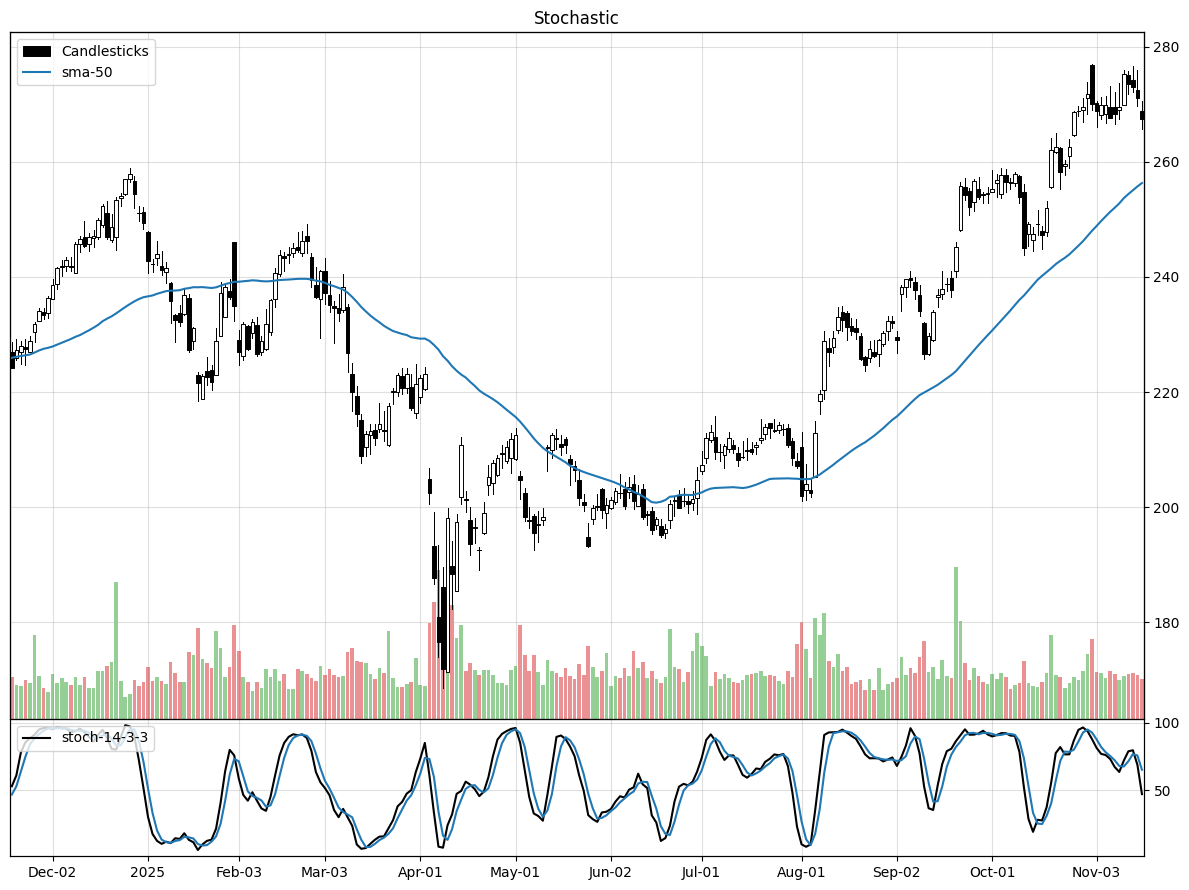

In [7]:
Chart(prices, title="Stochastic", max_bars=250).plot(
    Candlesticks(), SMA(50), Volume(),
).pane("below").plot(
    STOCH(),
).show()

## Rate of Change / Momentum

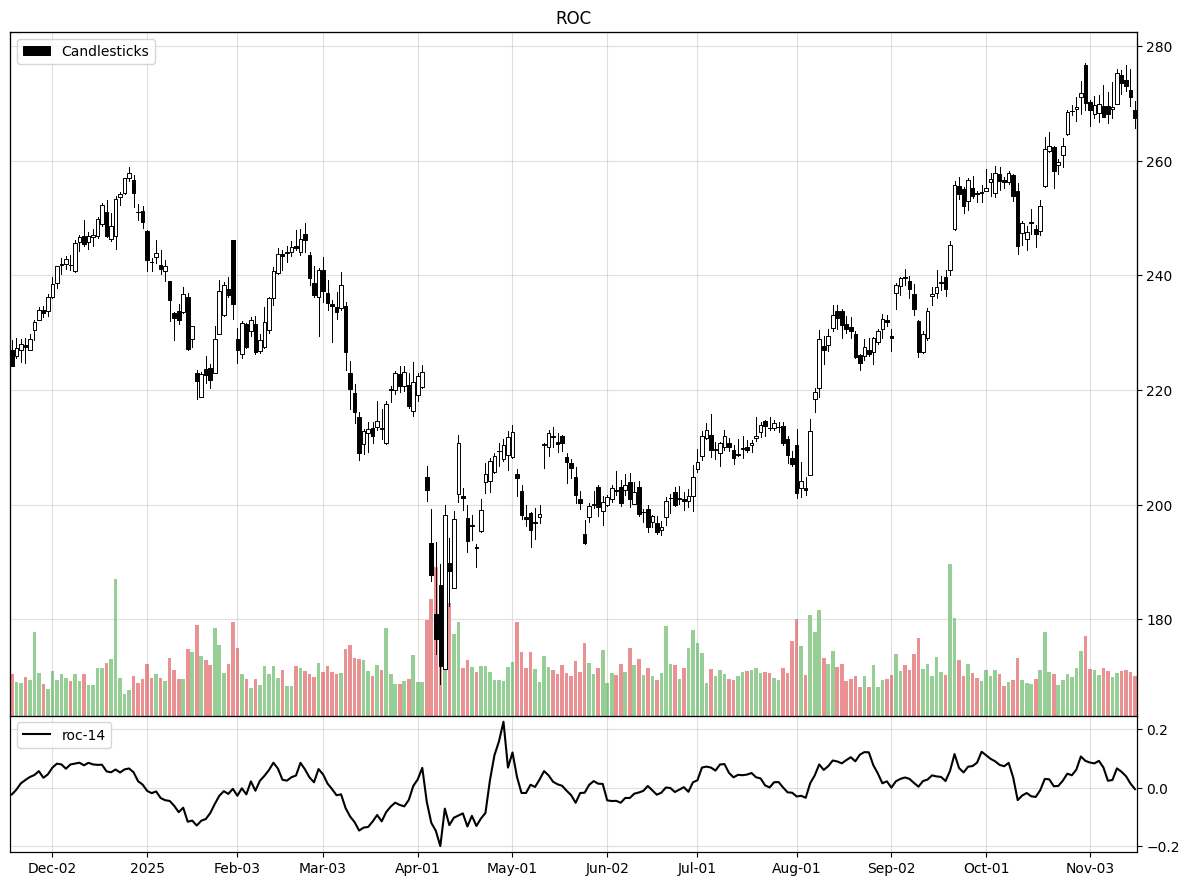

In [8]:
Chart(prices, title="ROC", max_bars=250).plot(
    Candlesticks(), Volume(),
).pane("below").plot(
    ROC(14),
).show()

## Bollinger Bands

`BBANDS` returns `(upperband, middleband, lowerband)`.

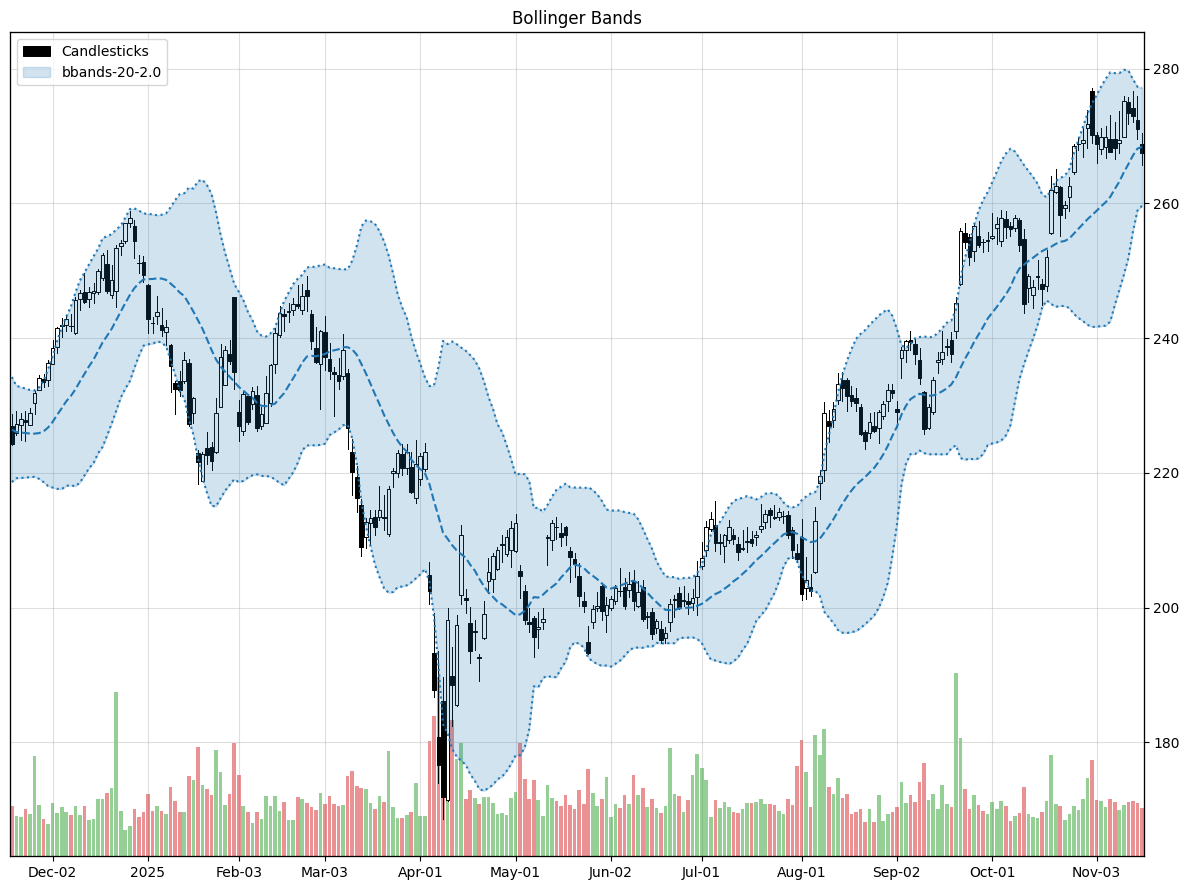

In [9]:
Chart(prices, title="Bollinger Bands", max_bars=250).plot(
    Candlesticks(), Volume(), BBANDS(),
).show()

## Donchian Channel

Highest high / lowest low over a lookback period — returns `(upperband, middleband, lowerband)`.

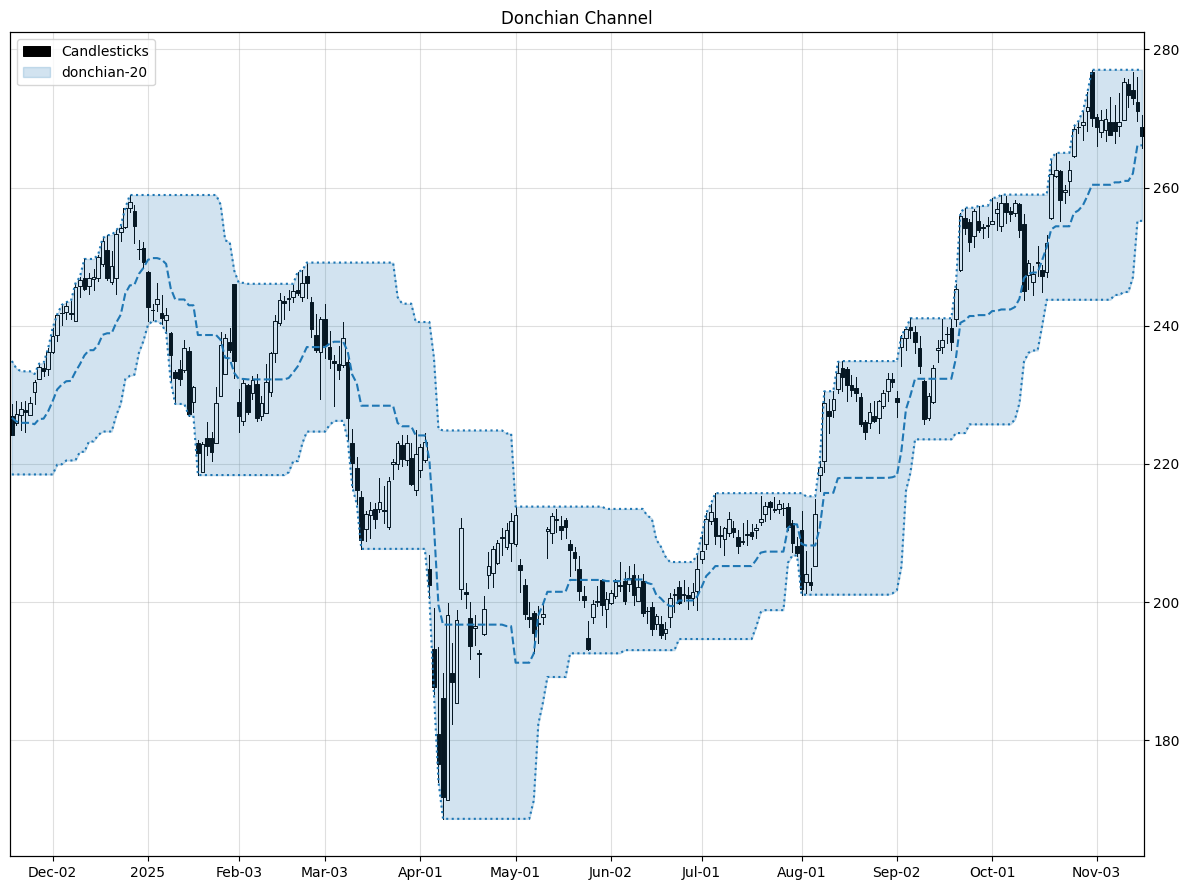

In [10]:
Chart(prices, title="Donchian Channel", max_bars=250).plot(
    Candlesticks(), DONCHIAN(),
).show()

## Keltner Channel

EMA-based channel using ATR for band width — returns `(upperband, middleband, lowerband)`.

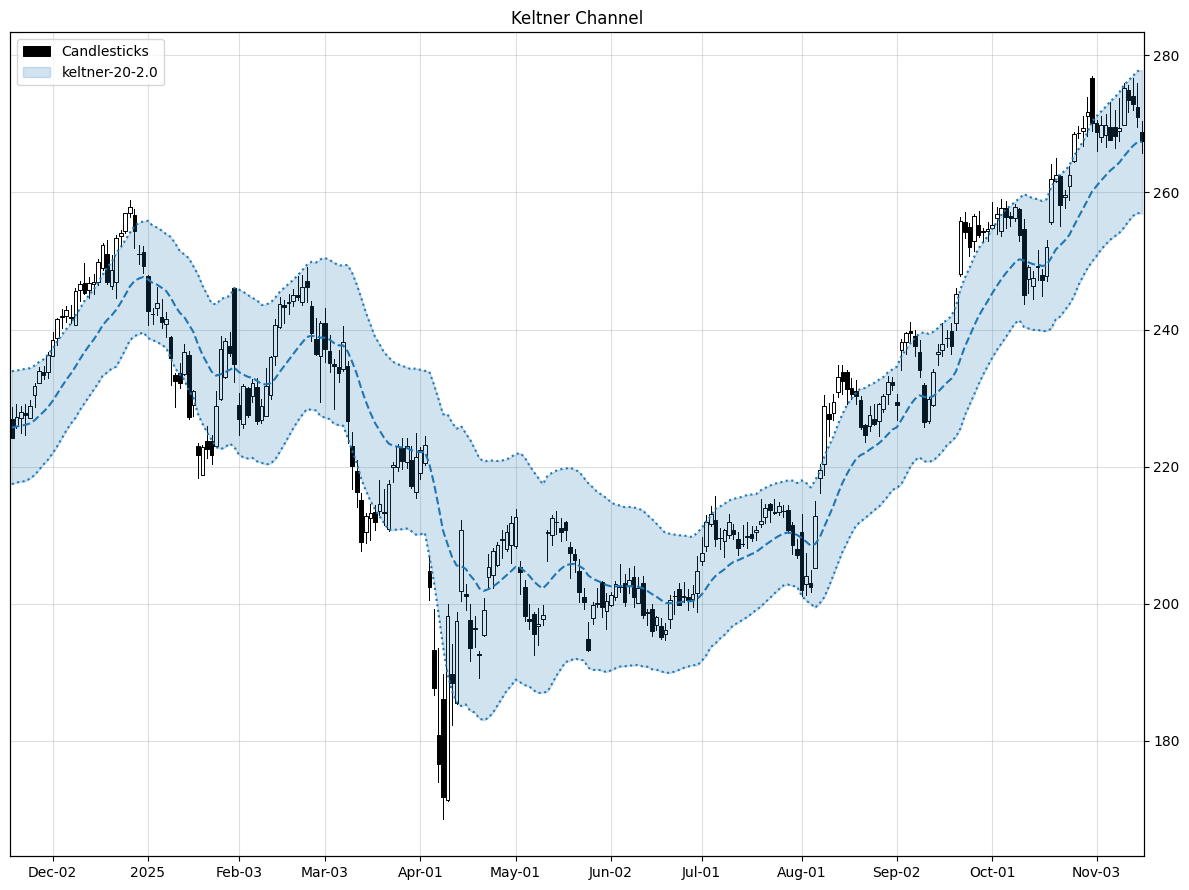

In [11]:
Chart(prices, title="Keltner Channel", max_bars=250).plot(
    Candlesticks(), KELTNER(),
).show()

## ATR / True Range

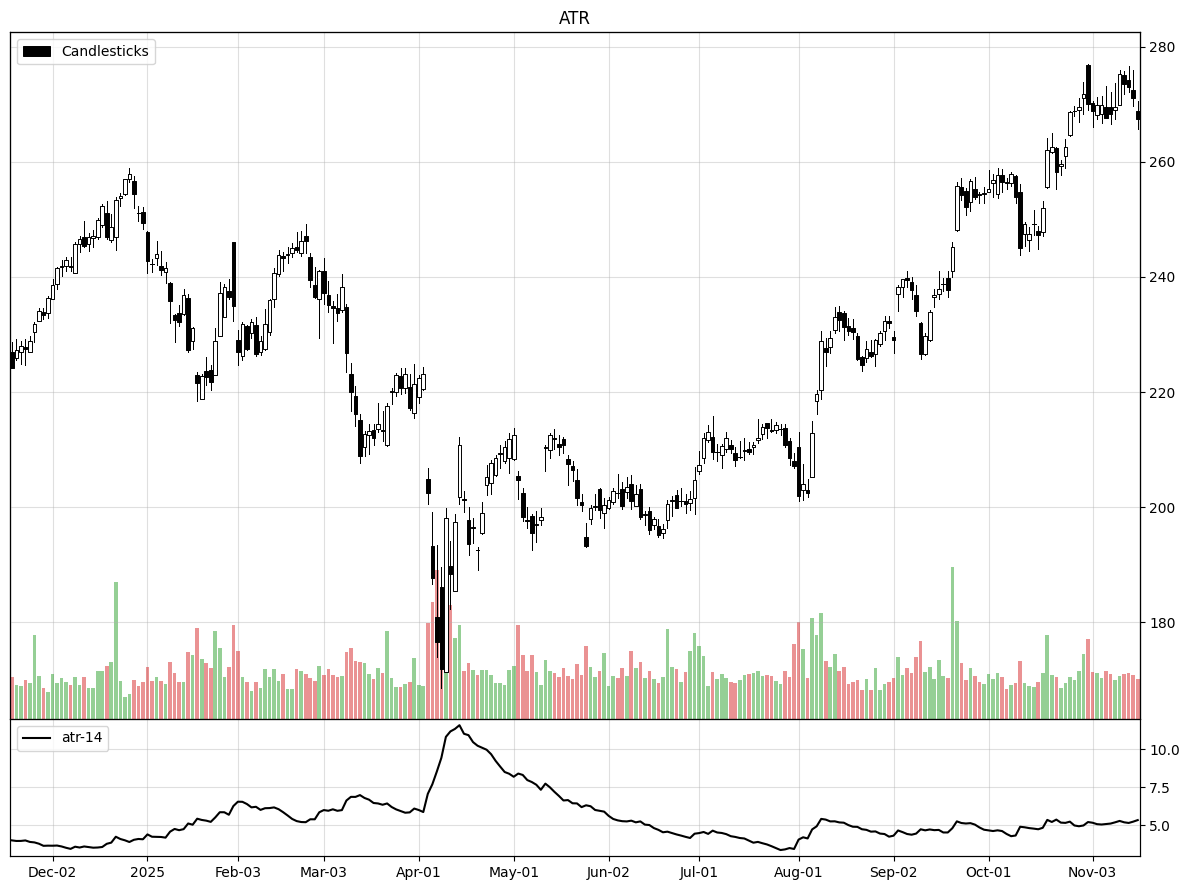

In [12]:
Chart(prices, title="ATR", max_bars=250).plot(
    Candlesticks(), Volume(),
).pane("below").plot(
    ATR(14),
).show()

## Price Series

`MEDPRICE` (HL/2), `TYPPRICE` (HLC/3), `WCLPRICE` (weighted close HLCC/4), `AVGPRICE` (OHLC/4).

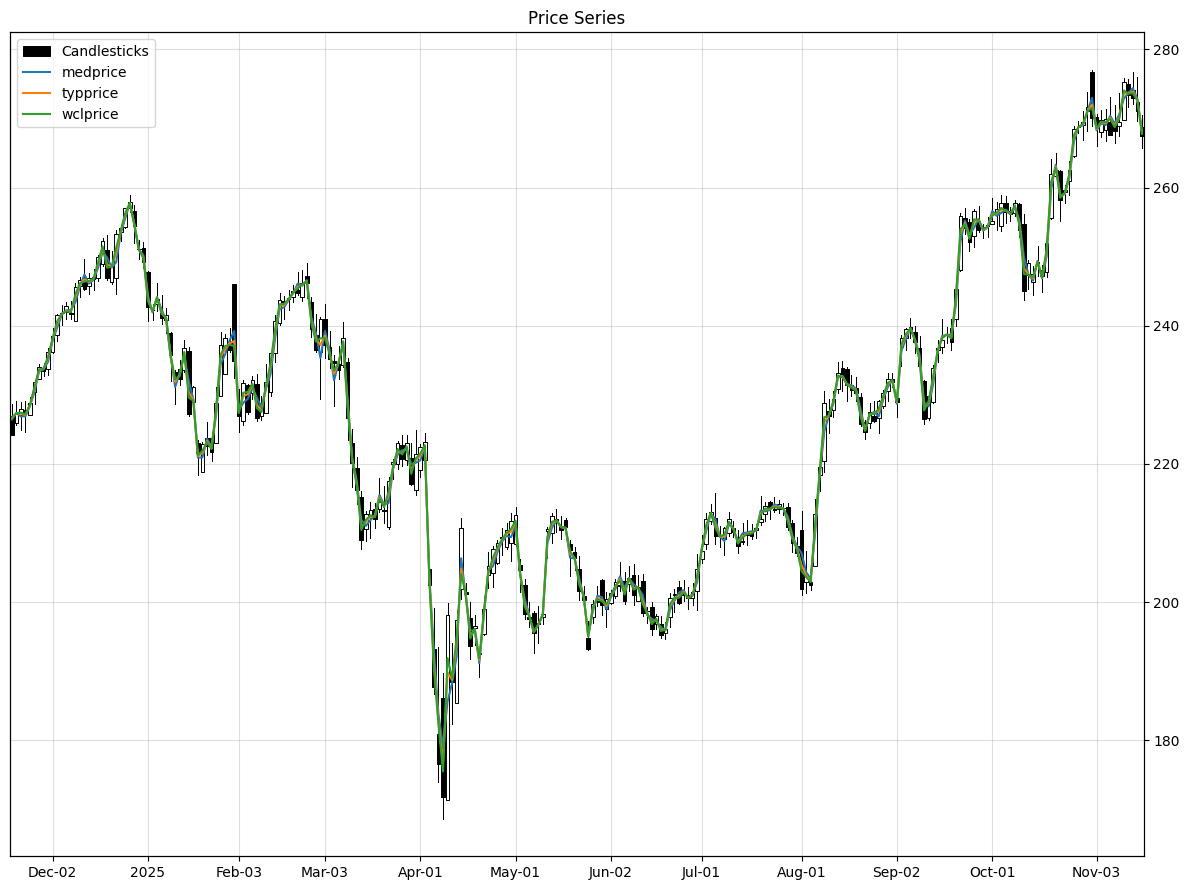

In [13]:
Chart(prices, title="Price Series", max_bars=250).plot(
    Candlesticks(),
    MEDPRICE(),
    TYPPRICE(),
    WCLPRICE(),
).show()

## Composing Expressions

Expressions can be composed by passing one as the `src` argument of another.

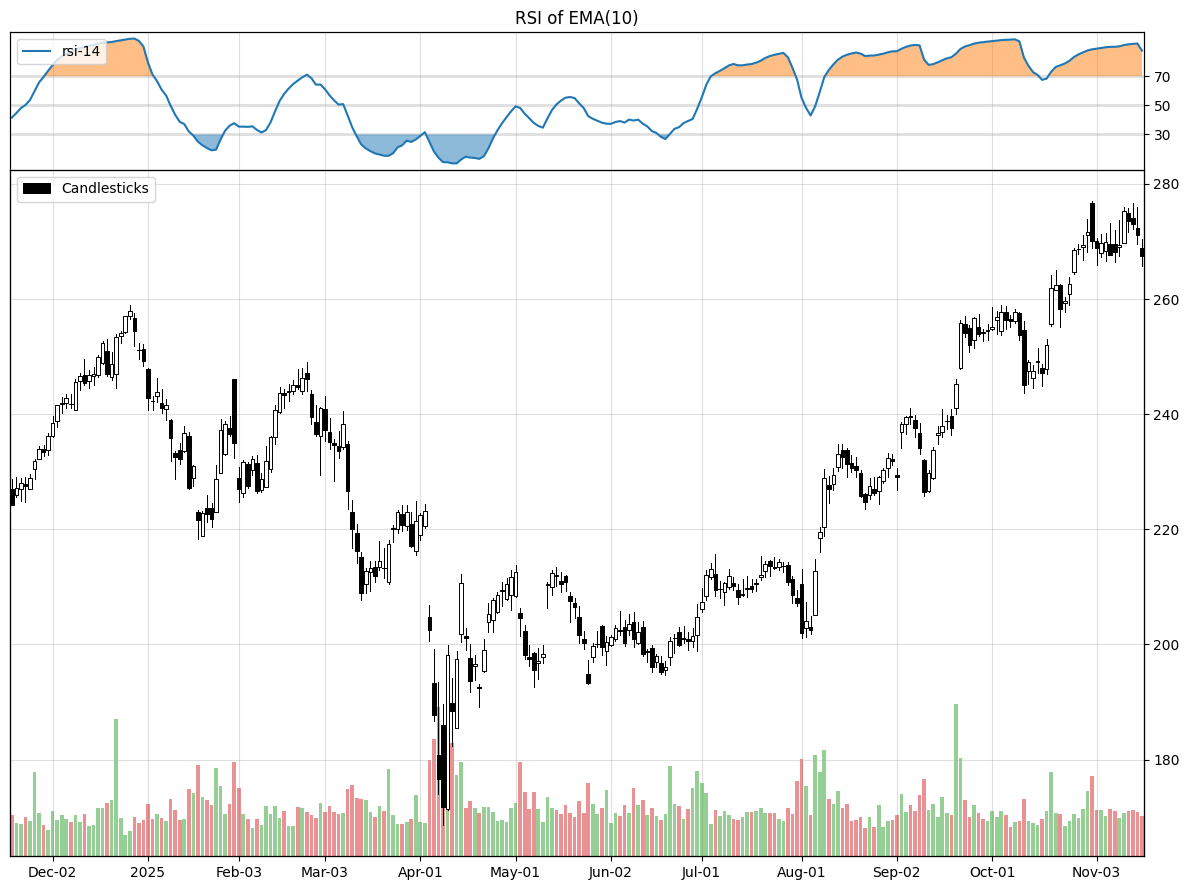

In [14]:
# RSI of EMA instead of close
Chart(prices, title="RSI of EMA(10)", max_bars=250).plot(
    Candlesticks(), Volume(),
).pane("above", yticks=(30, 50, 70)).plot(
    LinePlot(RSI(14, src=EMA(10)), overbought=70, oversold=30),
).show()

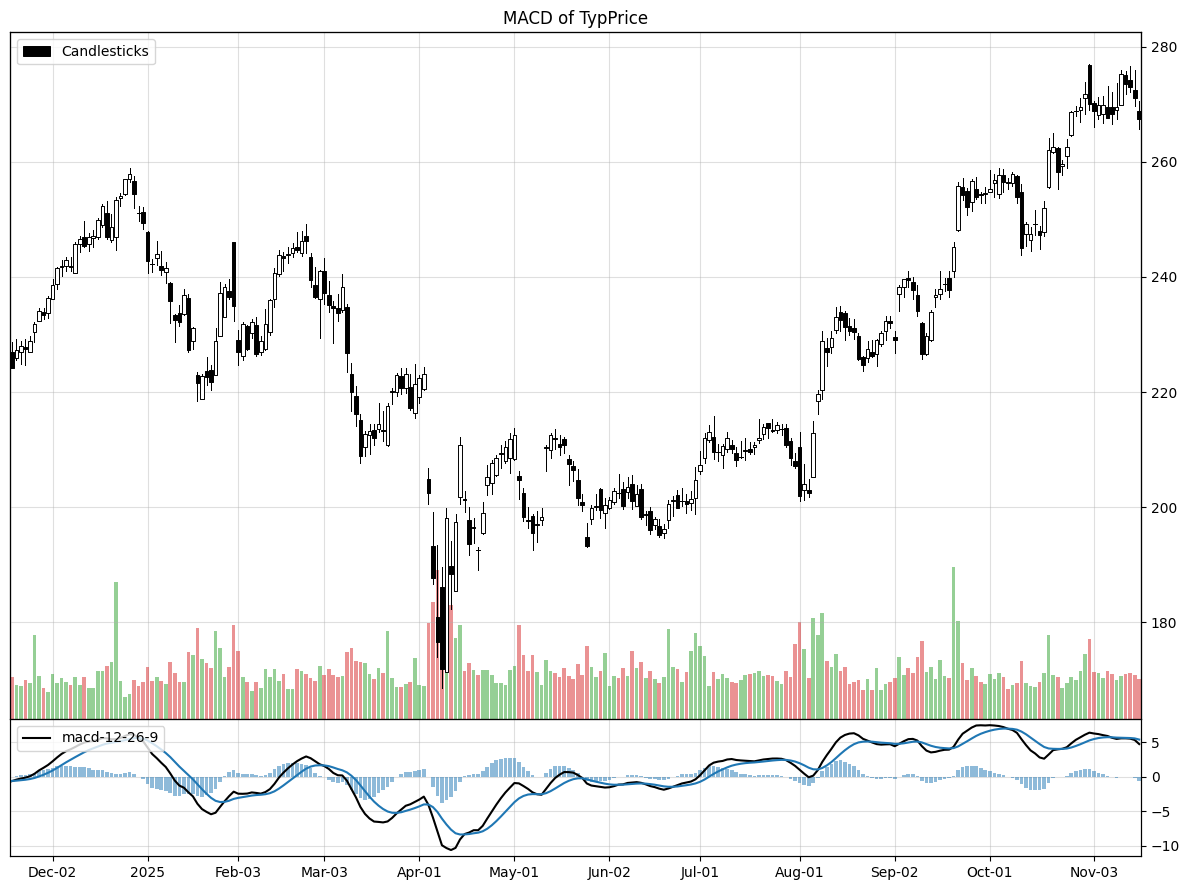

In [15]:
# MACD on typical price
Chart(prices, title="MACD of TypPrice", max_bars=250).plot(
    Candlesticks(), Volume(),
).pane("below").plot(
    MACD(12, 26, 9, src=TYPPRICE()),
).show()